Ahmed Bilal Azhar
23I-2581 DS-A
Lab 3

Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df = df.drop_duplicates()
df = df.dropna(subset=['Sales', 'Profit', 'Discount', 'Region', 'Category', 'Sub-Category'])
df.to_csv('superstore_cleaned.csv', index=False)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Task 1: Chart Types for Monthly Sales

In [2]:
monthly = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
monthly.index = monthly.index.to_timestamp()
monthly

Order Date
2014-01-01     14236.8950
2014-02-01      4519.8920
2014-03-01     55691.0090
2014-04-01     28295.3450
2014-05-01     23648.2870
2014-06-01     34595.1276
2014-07-01     33946.3930
2014-08-01     27909.4685
2014-09-01     81777.3508
2014-10-01     31453.3930
2014-11-01     78628.7167
2014-12-01     69545.6205
2015-01-01     18174.0756
2015-02-01     11951.4110
2015-03-01     38726.2520
2015-04-01     34195.2085
2015-05-01     30131.6865
2015-06-01     24797.2920
2015-07-01     28765.3250
2015-08-01     36898.3322
2015-09-01     64595.9180
2015-10-01     31404.9235
2015-11-01     75972.5635
2015-12-01     74919.5212
2016-01-01     18542.4910
2016-02-01     22978.8150
2016-03-01     51715.8750
2016-04-01     38750.0390
2016-05-01     56987.7280
2016-06-01     40344.5340
2016-07-01     39261.9630
2016-08-01     31115.3743
2016-09-01     73410.0249
2016-10-01     59687.7450
2016-11-01     79411.9658
2016-12-01     96999.0430
2017-01-01     43971.3740
2017-02-01     20301.1334
2

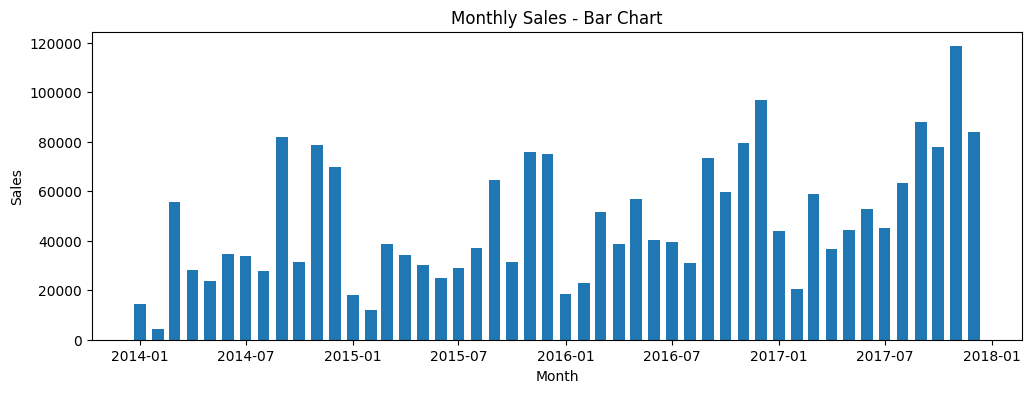

In [3]:
plt.figure(figsize=(12, 4))
plt.bar(monthly.index, monthly.values, width=20)
plt.title('Monthly Sales - Bar Chart')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

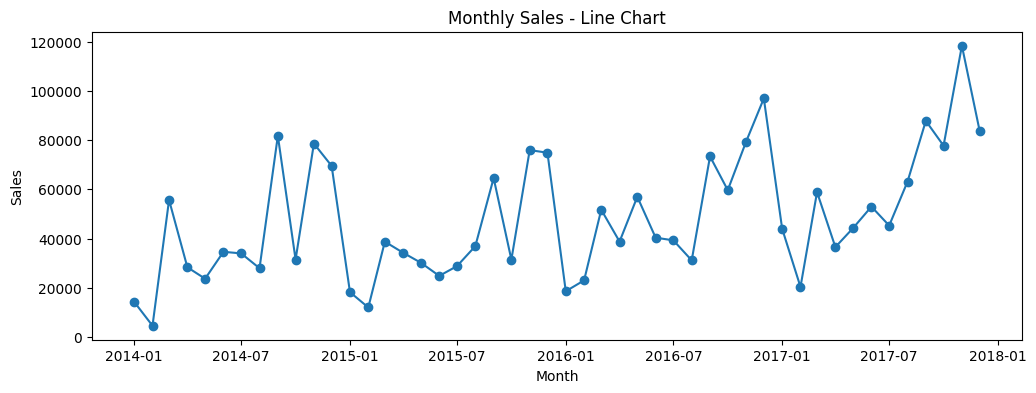

In [4]:
plt.figure(figsize=(12, 4))
plt.plot(monthly.index, monthly.values, marker='o')
plt.title('Monthly Sales - Line Chart')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

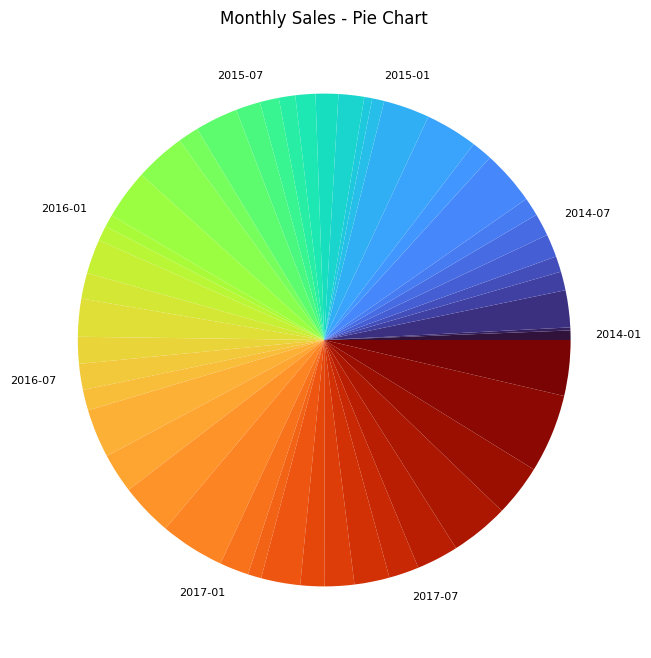

In [5]:
pie_colors = plt.cm.turbo(np.linspace(0, 1, len(monthly)))
pie_labels = []
i = 0
while i < len(monthly):
    if i % 6 == 0:
        pie_labels.append(monthly.index[i].strftime('%Y-%m'))
    else:
        pie_labels.append('')
    i = i + 1

plt.figure(figsize=(8, 8))
plt.pie(monthly.values, labels=pie_labels, colors=pie_colors, textprops={'fontsize': 8})
plt.title('Monthly Sales - Pie Chart')
plt.show()

The line chart shows the trend best because the points are connected in order and it is easy to see the ups and downs across months. The pie chart hides the trend completely since it has too many slices to read and gives no sense of time order, and the bar chart also gets cluttered with this many months.

## Task 2: Choosing the Right Chart

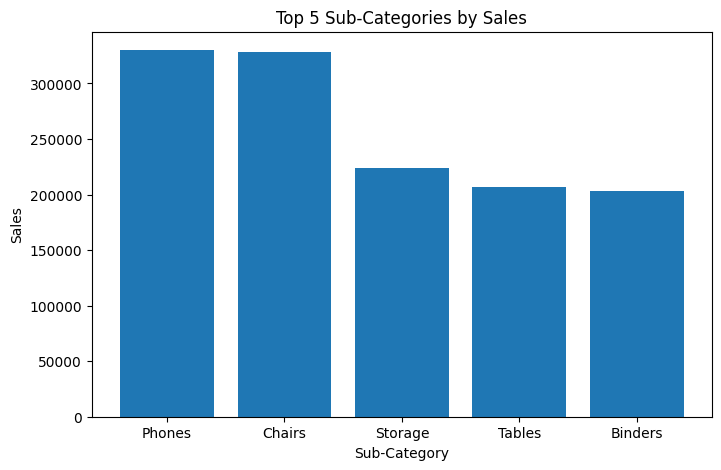

In [6]:
top5 = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(5)
plt.figure(figsize=(8, 5))
plt.bar(top5.index, top5.values)
plt.title('Top 5 Sub-Categories by Sales')
plt.xlabel('Sub-Category')
plt.ylabel('Sales')
plt.show()

A bar chart fits since it directly compares five totals by height. A pie chart would be a weaker choice here since judging small angle differences between five close wedges is harder than comparing bar heights.

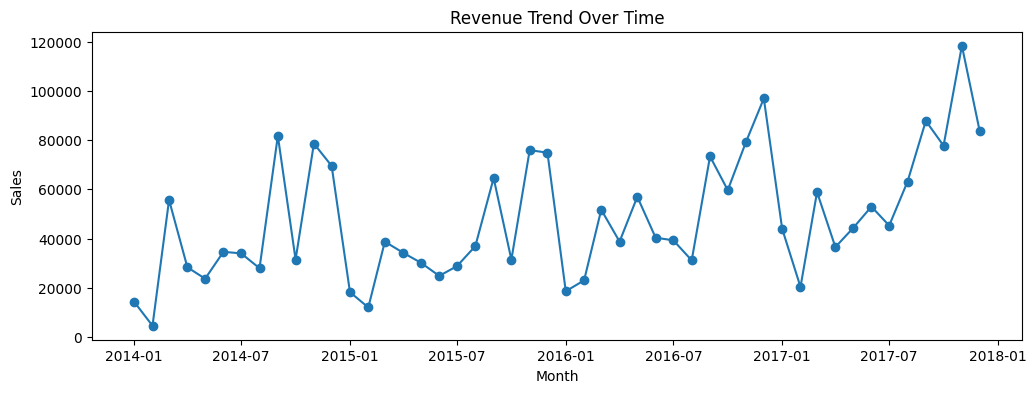

In [7]:
plt.figure(figsize=(12, 4))
plt.plot(monthly.index, monthly.values, marker='o')
plt.title('Revenue Trend Over Time')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

A line chart fits since revenue over time is a continuous sequence and the line shows direction and change clearly. A bar chart would be a weaker choice with this many time points since the bars become cluttered and the trend is harder to follow.

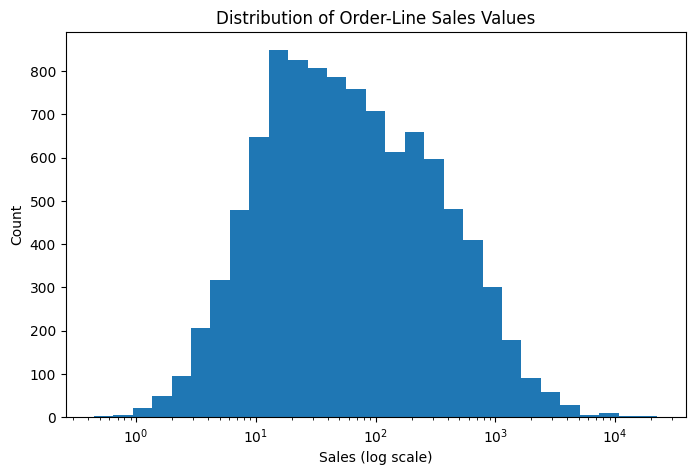

In [8]:
log_bins = np.logspace(np.log10(df['Sales'].min()), np.log10(df['Sales'].max()), 30)
plt.figure(figsize=(8, 5))
plt.hist(df['Sales'], bins=log_bins)
plt.xscale('log')
plt.title('Distribution of Order-Line Sales Values')
plt.xlabel('Sales (log scale)')
plt.ylabel('Count')
plt.show()

A histogram fits since it shows how the sales values are spread out and where most values fall. A bar chart of averages would be a weaker choice since it collapses the spread into a single number and hides how skewed the distribution is.

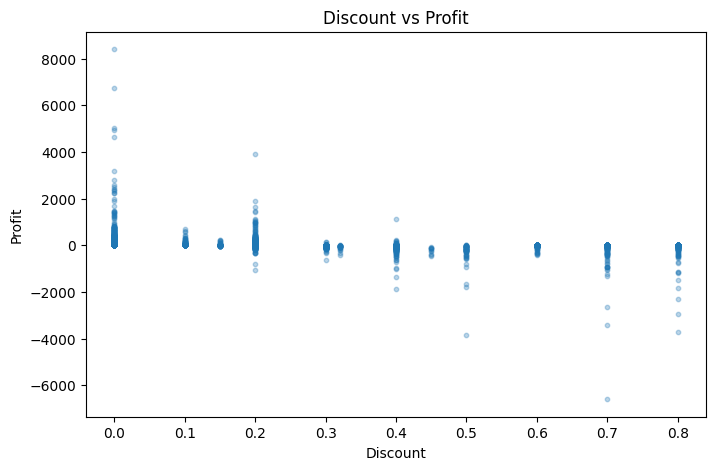

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Discount'], df['Profit'], alpha=0.3, s=10)
plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.show()

A scatter plot fits since it shows how two numeric variables relate across individual orders. A line chart would be a weaker choice since the orders have no natural sequence and connecting them with lines would imply an order that does not exist.

## Task 3: Color Selection

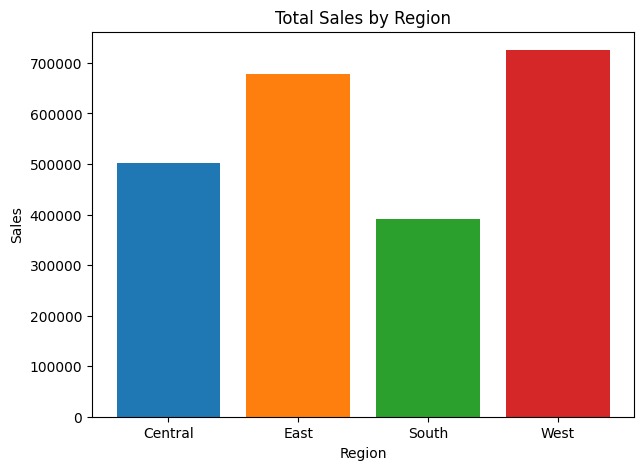

In [10]:
region_totals = df.groupby('Region')['Sales'].sum()
colors = plt.get_cmap('tab10').colors[:len(region_totals)]
plt.figure(figsize=(7, 5))
plt.bar(region_totals.index, region_totals.values, color=colors)
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.show()

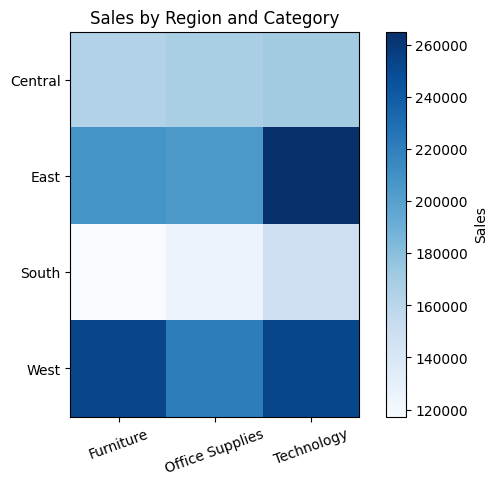

In [11]:
pivot = df.pivot_table(index='Region', columns='Category', values='Sales', aggfunc='sum')
plt.figure(figsize=(7, 5))
plt.imshow(pivot, cmap='Blues')
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=20)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.colorbar(label='Sales')
plt.title('Sales by Region and Category')
plt.show()

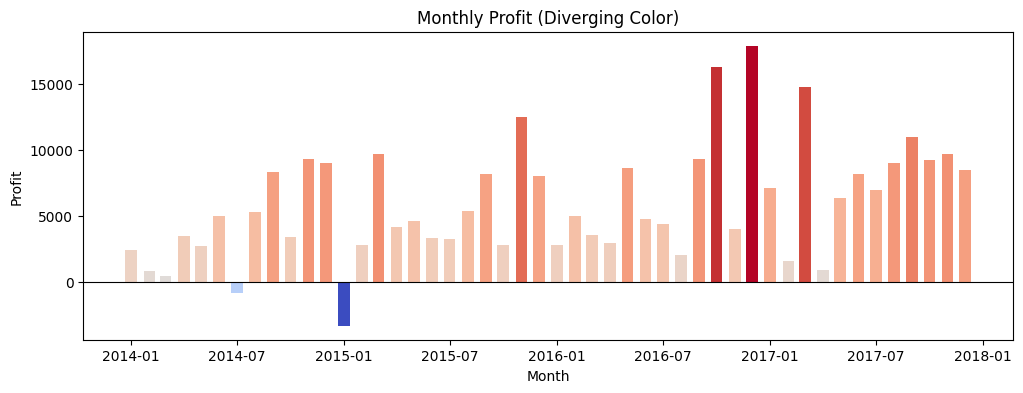

In [12]:
monthly_profit = df.groupby(df['Order Date'].dt.to_period('M'))['Profit'].sum()
monthly_profit.index = monthly_profit.index.to_timestamp()
norm = mcolors.TwoSlopeNorm(vmin=monthly_profit.min(), vcenter=0, vmax=monthly_profit.max())
bar_colors = plt.get_cmap('coolwarm')(norm(monthly_profit.values))
plt.figure(figsize=(12, 4))
plt.bar(monthly_profit.index, monthly_profit.values, color=bar_colors, width=20)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Monthly Profit (Diverging Color)')
plt.xlabel('Month')
plt.ylabel('Profit')
plt.show()

## Task 4: Accessibility Check

In [13]:
def rel_lum(rgb):
    vals = []
    for c in rgb:
        c = c / 255
        if c <= 0.03928:
            c = c / 12.92
        else:
            c = ((c + 0.055) / 1.055) ** 2.4
        vals.append(c)
    r, g, b = vals
    return 0.2126 * r + 0.7152 * g + 0.0722 * b

def contrast_ratio(rgb1, rgb2):
    l1 = rel_lum(rgb1)
    l2 = rel_lum(rgb2)
    lighter = max(l1, l2)
    darker = min(l1, l2)
    return (lighter + 0.05) / (darker + 0.05)

In [14]:
blues = plt.get_cmap('Blues')
light_rgba = blues(0.05)
dark_rgba = blues(0.95)
test_colors = {
    'region1': tuple(int(c * 255) for c in colors[0]),
    'region2': tuple(int(c * 255) for c in colors[1]),
    'region3': tuple(int(c * 255) for c in colors[2]),
    'region4': tuple(int(c * 255) for c in colors[3]),
    'heatmap_light': tuple(int(c * 255) for c in light_rgba[:3]),
    'heatmap_dark': tuple(int(c * 255) for c in dark_rgba[:3])
}
white = (255, 255, 255)
for name in test_colors:
    ratio = contrast_ratio(test_colors[name], white)
    status = 'pass' if ratio >= 4.5 else 'fail'
    print(name, round(ratio, 2), status)

region1 4.82 pass
region2 2.53 fail
region3 3.4 fail
region4 5.02 pass
heatmap_light 1.11 fail
heatmap_dark 10.75 pass


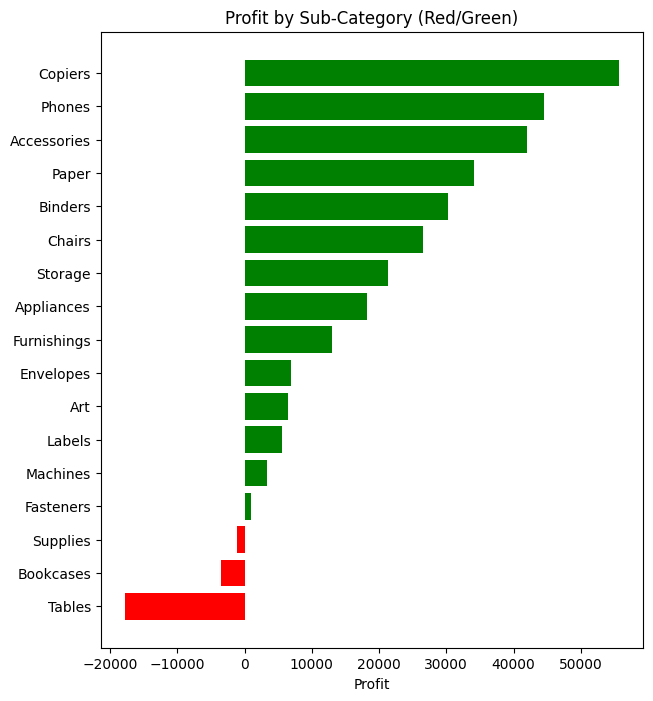

In [15]:
sub_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
rg_colors = ['red' if x < 0 else 'green' for x in sub_profit.values]
plt.figure(figsize=(7, 8))
plt.barh(sub_profit.index, sub_profit.values, color=rg_colors)
plt.title('Profit by Sub-Category (Red/Green)')
plt.xlabel('Profit')
plt.show()

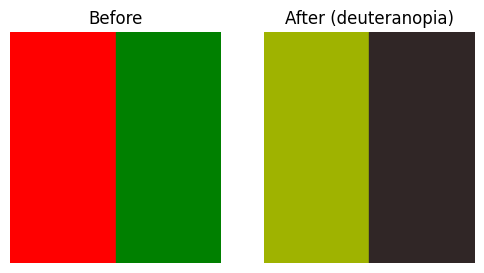

In [16]:
def simulate_deuteranopia(rgb):
    r, g, b = rgb
    r2 = 0.625 * r + 0.375 * g
    g2 = 0.7 * r + 0.3 * g
    b2 = 0.3 * g + 0.7 * b
    return (r2 / 255, g2 / 255, b2 / 255)

red_rgb = (255, 0, 0)
green_rgb = (0, 128, 0)
red_sim = simulate_deuteranopia(red_rgb)
green_sim = simulate_deuteranopia(green_rgb)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].add_patch(plt.Rectangle((0, 0), 1, 1, color=(1, 0, 0)))
axes[0].add_patch(plt.Rectangle((1, 0), 1, 1, color=(0, 0.5, 0)))
axes[0].set_xlim(0, 2)
axes[0].set_ylim(0, 1)
axes[0].set_title('Before')
axes[0].axis('off')
axes[1].add_patch(plt.Rectangle((0, 0), 1, 1, color=red_sim))
axes[1].add_patch(plt.Rectangle((1, 0), 1, 1, color=green_sim))
axes[1].set_xlim(0, 2)
axes[1].set_ylim(0, 1)
axes[1].set_title('After (deuteranopia)')
axes[1].axis('off')
plt.show()

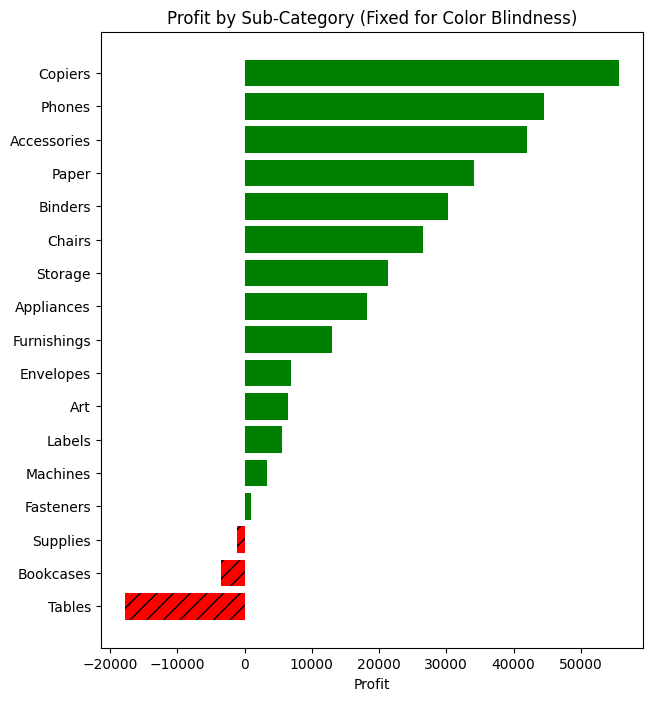

Horizontal bar chart of profit by sub-category, sorted from largest loss to largest gain. Loss bars are red with diagonal hatching and gain bars are green with no hatching, so the difference does not rely on color alone.


In [17]:
hatches = ['//' if x < 0 else '' for x in sub_profit.values]
plt.figure(figsize=(7, 8))
bars = plt.barh(sub_profit.index, sub_profit.values, color=rg_colors)
for bar, hatch in zip(bars, hatches):
    bar.set_hatch(hatch)
plt.title('Profit by Sub-Category (Fixed for Color Blindness)')
plt.xlabel('Profit')
plt.show()

alt_text = 'Horizontal bar chart of profit by sub-category, sorted from largest loss to largest gain. Loss bars are red with diagonal hatching and gain bars are green with no hatching, so the difference does not rely on color alone.'
print(alt_text)

## Task 5: Misleading Visualizations

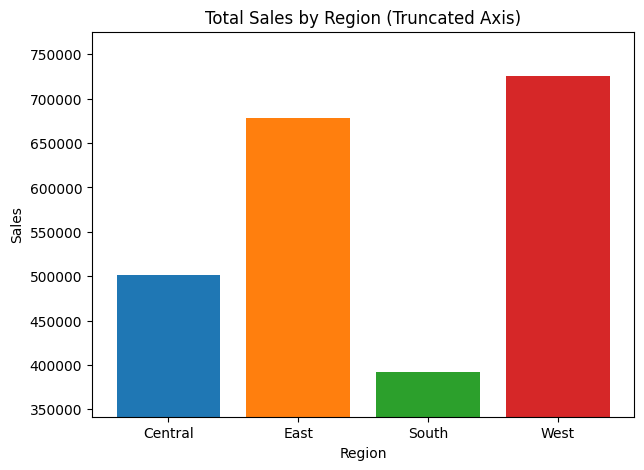

Truncated y-axis: the axis starts near the smallest region total instead of zero, which exaggerates the gap between regions.


In [18]:
pad = (region_totals.max() - region_totals.min()) * 0.15
plt.figure(figsize=(7, 5))
plt.bar(region_totals.index, region_totals.values, color=colors)
plt.ylim(region_totals.min() - pad, region_totals.max() + pad)
plt.title('Total Sales by Region (Truncated Axis)')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.show()
print('Truncated y-axis: the axis starts near the smallest region total instead of zero, which exaggerates the gap between regions.')

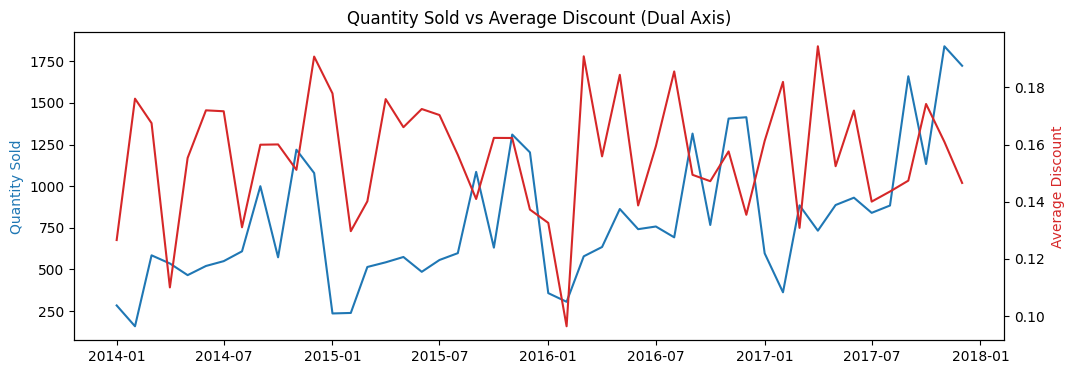

Dual y-axes: quantity sold and average discount are unrelated measures placed on separate scales, which makes them look like they move together when they may not.


In [19]:
monthly_qty = df.groupby(df['Order Date'].dt.to_period('M'))['Quantity'].sum()
monthly_qty.index = monthly_qty.index.to_timestamp()
monthly_discount = df.groupby(df['Order Date'].dt.to_period('M'))['Discount'].mean()
monthly_discount.index = monthly_discount.index.to_timestamp()

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(monthly_qty.index, monthly_qty.values, color='tab:blue')
ax1.set_ylabel('Quantity Sold', color='tab:blue')
ax2 = ax1.twinx()
ax2.plot(monthly_discount.index, monthly_discount.values, color='tab:red')
ax2.set_ylabel('Average Discount', color='tab:red')
plt.title('Quantity Sold vs Average Discount (Dual Axis)')
plt.show()
print('Dual y-axes: quantity sold and average discount are unrelated measures placed on separate scales, which makes them look like they move together when they may not.')

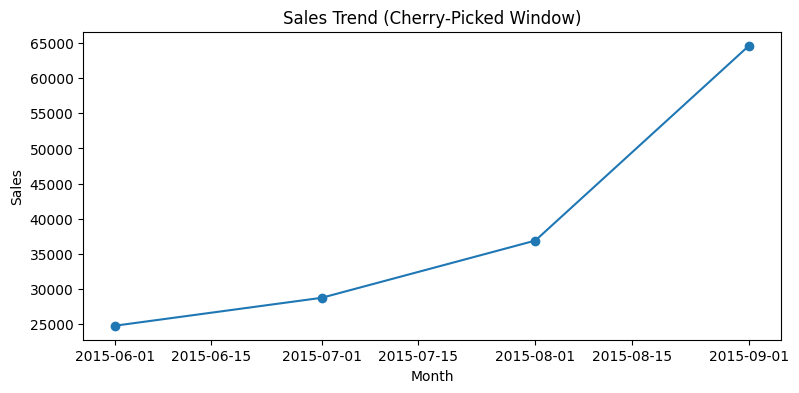

Cherry-picked window: only Jun-Sep 2015 is shown, which looks like steady uninterrupted growth, but sales actually dropped sharply in the month right before this window and the month right after it.


In [20]:
window = monthly[(monthly.index >= '2015-06-01') & (monthly.index <= '2015-09-01')]
plt.figure(figsize=(9, 4))
plt.plot(window.index, window.values, marker='o')
plt.title('Sales Trend (Cherry-Picked Window)')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()
print('Cherry-picked window: only Jun-Sep 2015 is shown, which looks like steady uninterrupted growth, but sales actually dropped sharply in the month right before this window and the month right after it.')

## Task 6: Honest vs Misleading Chart

Analytical question: is discounting hurting profit?

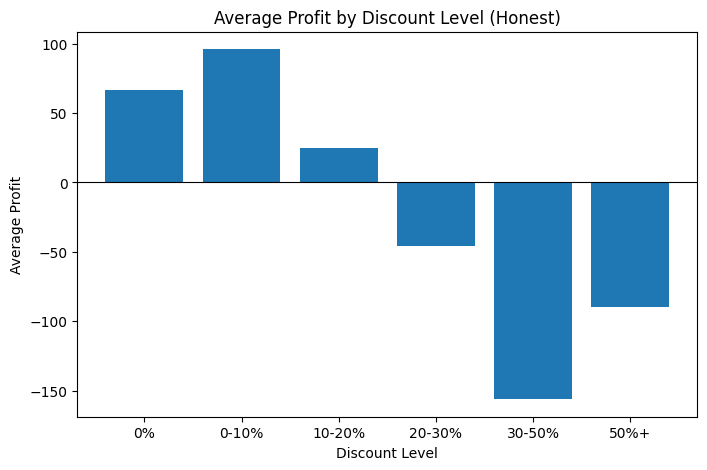

In [21]:
bins = [-0.01, 0, 0.1, 0.2, 0.3, 0.5, 1]
labels = ['0%', '0-10%', '10-20%', '20-30%', '30-50%', '50%+']
df['discount_bin'] = pd.cut(df['Discount'], bins=bins, labels=labels)
avg_profit = df.groupby('discount_bin', observed=True)['Profit'].mean()

plt.figure(figsize=(8, 5))
plt.bar(avg_profit.index.astype(str), avg_profit.values, color='tab:blue')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Average Profit by Discount Level (Honest)')
plt.xlabel('Discount Level')
plt.ylabel('Average Profit')
plt.show()

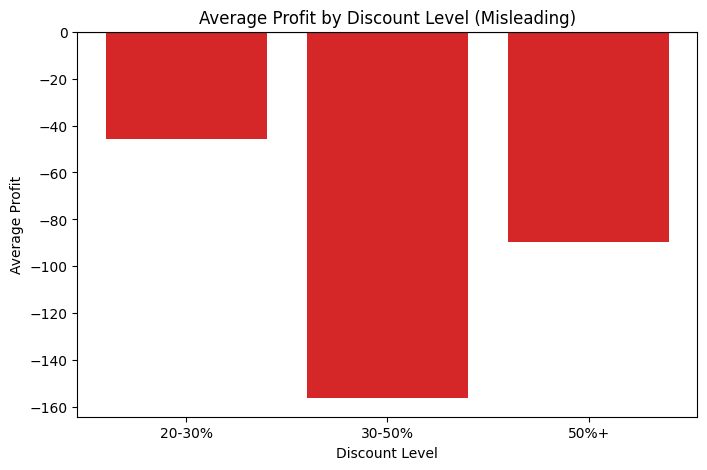

In [22]:
high_discount_only = avg_profit[['20-30%', '30-50%', '50%+']]
plt.figure(figsize=(8, 5))
plt.bar(high_discount_only.index.astype(str), high_discount_only.values, color='tab:red')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Average Profit by Discount Level (Misleading)')
plt.xlabel('Discount Level')
plt.ylabel('Average Profit')
plt.show()

The honest chart uses a bar chart starting at zero with every discount level shown, so it is clear that small discounts (0-20%) are still profitable on average and only discounts above roughly 20% turn profit negative. The misleading version only plots the 20-30%, 30-50%, and 50%+ bins and drops the profitable low-discount bins entirely, which falsely implies that discounting always hurts profit. A single blue hue is used in the honest chart since discount level is an ordered variable rather than unrelated categories, and a black zero line marks the break-even point instead of relying on color alone, so it still reads correctly for a colorblind viewer. Running the earlier contrast function on that blue against a white background gives a ratio above 4.5:1, so it passes the WCAG AA check.